<img src="./logo_UTN.svg" align="right" width="150" /> 

### Teoría de Circuitos II

# Trabajo Practico de Laboratorio

Autor: *Olea Gasalla Ignacio Ezequiel y Mariano Lapilli*

*Fecha de entrega: viernes 21 de agosto de 2026*

#### **Consigna** 
##### **Análisis y Simulacion ( Pre-Lab )**
1. Obtener el orden del filtro y hallar la función transferencia total.

2. Obtener la transferencia de la red circuital a implementar.

3. Simulación numérica/simbólica de la función transferencia en Python.

4. Simulación circuital. Incluya el modelo real del OPAMP.

##### **Implementacion y armado ( Pre-Lab )**
1. Disenar el Layout del PCB.

2. Usar conectores, headers o borneras para alimentar el filtro, introducir la señal de entrada, medir la señal de entrada y salida ( test points )

3. Utilizar un zócalo DIP 14 para colocar el OPAMP y DIP 16 para el OTA.

4. Incluir resistores variables ( presets / trimmer ) o bien resistores fijos con tolerancias del 1%.

5. Agregar capacitores de bypass en la alimentacion del Amplificador. Agregar capacitor electrolítico o poliéster de 1 µF a 100 µF con otro cerámico de 100 nF a 470 nF en paralelo para reducir el ruido de la fuente.

##### **Medicion ( In-Lab )**
1. Verificar visualmente y con el multímetro que el circuito no tiene cortocircuitos y que los componentes estén correctamente soldados.

2. Utilice la limitación de corriente de la fuente en algunas decenas de mA. Para ello se debe poner en corto los bornes de + y - a una tensión baja por ejemplo 1 V. De esta manera el equipo entra en modo CC ( corto circuito ) y se puede setear el nivel de corriente.

3. Setear la tensión de la fuente. Utilice un multímetro para ajustar la tensión de la fuente. Finalmente alimente su circuito. Tenga en cuenta que la medición mejora para niveles más altos de fuente.

4. Verifique las puntas del osciloscopio. Utilice la señal de prueba tanto en el canal 1 como 2 para ajustar la respuesta temporal visualizada. Verifique el valor de AC y periodo de esta señal de prueba con los medidores del DSO.

5. Calibre una señal senoidal en el generador a un nivel que optimice la medición en la banda de paso de valor medio nulo con el generador. Tenga en cuenta que el filtro puede generar sobretensiones a la salida.

6. Desenergice el circuito si así estuviera y conecte el integrado. Conecte la alimentación nuevamente y el generador de entrada. Verifique que el DSO tenga señal a la salida. Debe ser de la misma forma ( sin distorsión ) que la entrada con una cierta fase y alguna diferencia de amplitud probablemente.

7. Llegado a este punto está en condiciones de realizar un barrido con frecuencia :D


##### **Anexo**:
📎 En caso de no poder acceder al documento, presione aquí: [Mostrar PDF](./tc2_ts3.pdf)

📎 Recordar ejecutar el cuadro siguiente de librerias:

In [4]:
# Importo las librerias
import math
import sympy as sp
import numpy as np
import pandas as pd
import scipy.signal as sig
import matplotlib.pyplot as plt
from sympy import Eq
from IPython.display import display, IFrame, Math
from matplotlib import pyplot as plt
from scipy.signal import TransferFunction
from scipy.interpolate import make_interp_spline

from pytc2.sistemas_lineales import pretty_print_lti, pzmap, GroupDelay, bodePlot, pretty_print_SOS, tf2sos_analog, pretty_print_bicuad_omegayq,tf2zpk, parametrize_sos, analyze_sys
from pytc2.general import s, w, print_latex, a_equal_b_latex_s, print_subtitle, Chebyshev_polynomials

# Función para mostrar en formato de ingenieria las unidades
def eng_format(value, unit=""):
    import numpy as np
    if value == 0:
        return f"0 {unit}"
    exp = int(np.floor(np.log10(abs(value)) / 3) * 3)
    scaled = value / (10**exp)
    prefixes = {-12: "p",-9: "n",-6: "u",-3: "m",0: "",3: "k",6: "M",9: "G"}
    prefix = prefixes.get(exp, f"e{exp}")
    return f"{scaled:.1f} {prefix}{unit}"

#--------------------------------------------------------------------------

## **Resolución**

Se eligió el filtro Notch y se sintetizará mediante la topología **Twin T**

<img src="./filtro.png" /> 

#### **Función transferencia**
En el siguiente bloque de código se encuentra el valor de la transferencia con los componentes con valores generales y con los valores usados, además de un gráfico de como se desarrolla la transferencia con los valores utilizados:


Función transferencia con componentes simbólicos:


Eq(T(s), (C**3*R**3*R0*s**3 + C**3*R**3*R1*s**3 + C**2*R**2*R0*s**2 + C**2*R**2*R1*s**2 + C*R*R0*s + C*R*R1*s + R0 + R1)/(C**3*R**3*R0*s**3 + C**3*R**3*R1*s**3 + C**2*R**2*R0*s**2 + 5*C**2*R**2*R1*s**2 + C*R*R0*s + 5*C*R*R1*s + R0 + R1))


Función transferencia y componentes utilizados:


Eq(T(s), (1.0*s**2 + 9.183e+4)/(1.0*s**2 + 64.28*s + 9.183e+4))

   C  = 10.0 uF 
   R  = 330.0 Ω 
   R0 = 10.0 kΩ 
   R1 = 560.0 Ω 

Función transferencia usada para el gráfico:


<IPython.core.display.Math object>

[[1,
  array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
         <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia [Hz]', ylabel='Fase [rad]'>],
        dtype=object)],
 [2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>],
 [3, []],
 [4,
  <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia [Hz]', ylabel='Retardo de grupo [seg]'>]]

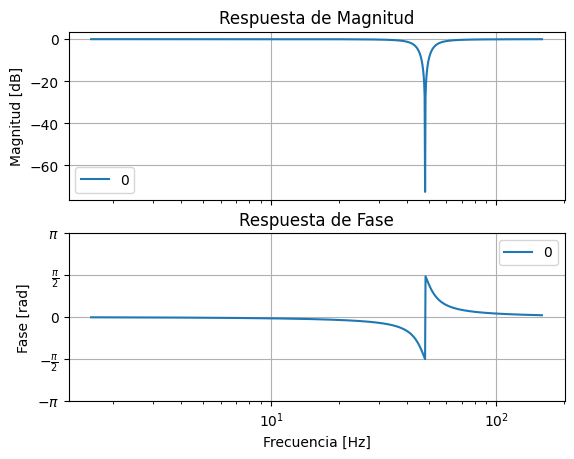

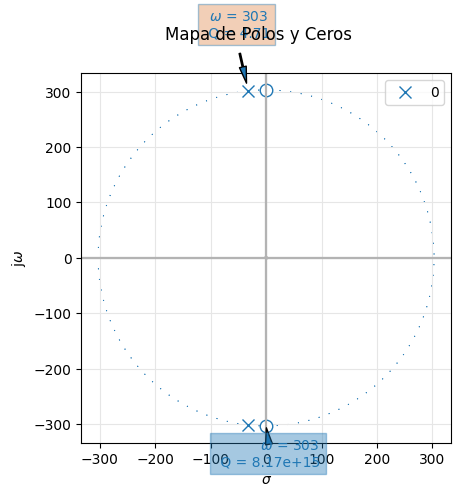

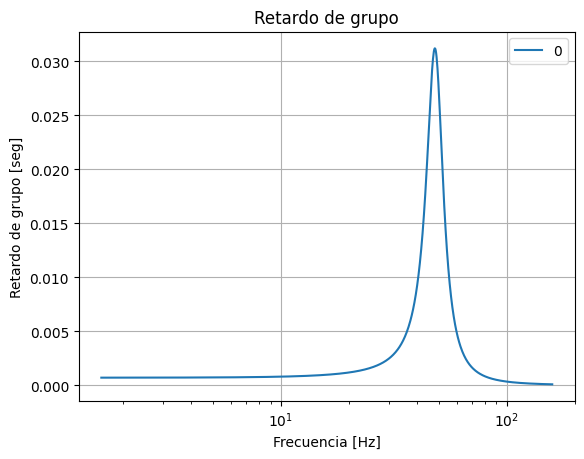

In [43]:
# Se declaran variable simbolicas:
s = sp.symbols('s')
C1, C2, C3, R0, R1, R2, R3, R4 = sp.symbols('C1 C2 C3 R0 R1 R2 R3 R4', positive=True, real=True)
Vi, Vo, V1, V2, Vx = sp.symbols('Vi Vo V1 V2 Vx')

G0 = 1/R0
G1 = 1/R1
G2 = 1/R2
G3 = 1/R3
G4 = 1/R4

# Se expresa las ecuaciones de nodos:
#eq1 = (Vx - Vi)*G0 + (Vx - V2)*G2 + (Vx - V1)*s*C1 
eq1 = (Vi - Vx)*G0 + (Vi - Vo)*G1  # E
eq2 = (V1 - Vx)*s*C1 + (V1 - Vo)*s*C2 + V1*G4 
eq3 = (V2 - Vx)*G2 + (V2 - Vo)*G3 + V2*s*C3 
eq4 = (Vo - V2)*G3 + (Vo - V1)*s*C2 

sol = sp.solve([eq1, eq2, eq3, eq4], (V1 , V2 , Vx, Vo))
# -------------------------------------------------------------------------------------------------------------------------------

# Se arma la transferencia: 
H = sp.simplify(sol[Vo] / Vi) 

C, R = sp.symbols('C R', positive=True, real=True)

C1_ = C
C2_ = C
C3_ = 2*C
R2_ = R
R3_ = R
R4_ = R/2

# Se reemplazan los componentes simbolicos:
H = sp.simplify(H).subs({ R2:(R2_) , R3:(R3_) , R4:(R4_) , C1:(C1_) , C2:(C2_) , C3:(C3_) })

# Se imprime la transferencia:
print('\n'rf"Función transferencia con componentes simbólicos:")
display(Eq(sp.Function('T')(s), H))


# Valores usados:
f0 = 50 # 50 Hz
B  = 10 # 10 Hz

C_  = 10e-6
R1_ = 560
R_  = 330                             # 1 / (2*np.pi*f0 * C_)
R0_ = 10e3                            # (4* (f0 / B) -1) * R1_ 

# Se reemplazan los componentes con los valores necesarios:
H = sp.simplify(H).subs({ R:(R_) , R0:(R0_) , R1:(R1_) , C:(C_) }).evalf(4)

# Se imprime de forma mónica la trasferencia:
num, den = H.as_numer_denom()
coef = sp.Poly(den, s).all_coeffs()[0]
H = sp.simplify((num/coef) / (den/coef))
print('\n'rf"Función transferencia y componentes utilizados:")
display(Eq(sp.Function('T')(s), H))

print(rf"   C  = {eng_format(C_ , 'F')} ")
print(rf"   R  = {eng_format(R_ , 'Ω')} ")
print(rf"   R0 = {eng_format(R0_, 'Ω')} ")
print(rf"   R1 = {eng_format(R1_, 'Ω')} ")

# Se ingresa la transferencia para el gráfico:
num_ = [ 1 , 0 , 9.183e4 ]
den_ = [ 1 , 64.28 , 9.183e4 ]

# Se grafica la transferencia obtenida:
mi_tf = sig.TransferFunction(num_,den_)
this_sos = tf2sos_analog(num_, den_)
print('\n'rf"Función transferencia usada para el gráfico:")
pretty_print_SOS(this_sos, mode='omegayq')
analyze_sys( mi_tf , xaxis='freq' )

#### **Simulación**
Como simulación circuital utilizamos un operacional genérico al no poder importar el LM324 a LTSpice:

<img src="./simucirc.png" /> 

<img src="./simu.png" /> 

#### **Laboratorio**
Una vez en el laboratorio:

-Se obtuvo el archivo CSV del Analizador de Audio.

-Se tomaron 20 muestras con el Osciloscopio a distintas frecuencias:

<img src="./resultados.png" /> 

Por ultimo, se compararon ambas gráficas con la transferencia matemática ideal con los componentes que utilizamos (calculada más arriba).

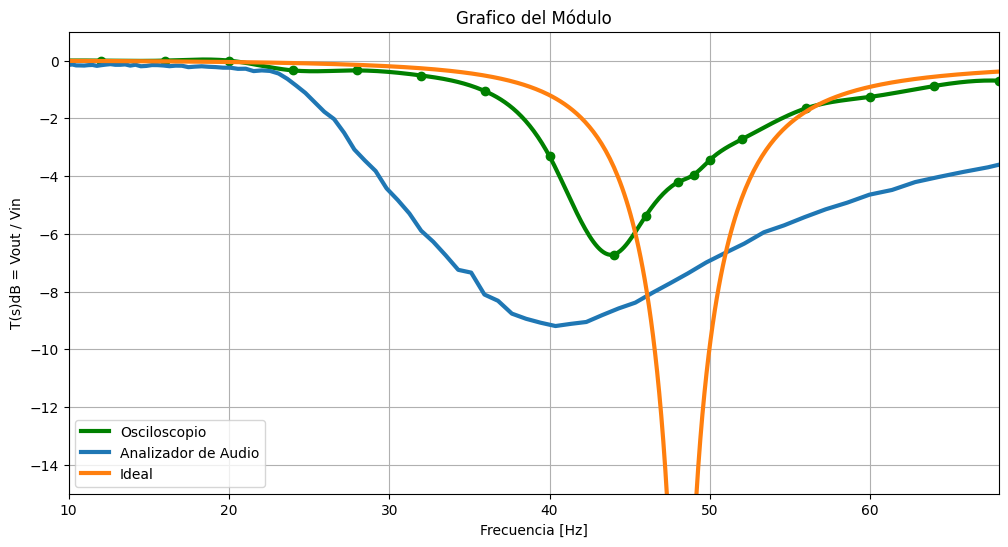

In [26]:
# ----------------------------
# -----  Gráfico 1: ----------
#-----------------------------
    # Gráfico hecho con las mediciones del Osciloscopio
# Datos:
frecuencia_1 = np.array([ 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 46, 48, 49, 50, 52, 56, 60, 64, 68 ])
Vout = np.array([ 520, 520, 520, 520, 520, 500, 500, 490, 460, 355, 240, 280, 320, 330, 350, 380, 430, 450, 470, 480])
Vin = 520  # mV

# Transferencia punto a punto
H = 20*np.log10(Vout / Vin)

# Curva suave
f_suave = np.linspace(frecuencia_1.min(), frecuencia_1.max(), 500)
H_suave = make_interp_spline(frecuencia_1, H)(f_suave)

plt.figure(figsize=(12, 6))

plt.plot(frecuencia_1, H, 'o', color='green')
plt.plot(f_suave, H_suave, color='green', label='Osciloscopio', lw=3)

# ----------------------------
# -----  Gráfico 2: ----------
#-----------------------------
    # Gráfico hecho con el archivo modulo.csv medido en el laboratorio con el Analizador de Audio
datos = pd.read_csv('modulo.csv', skiprows=2)

frecuencia_2 = datos['X (Hz)']
H_dB = datos['Ch-1 (dBr)']

plt.plot(frecuencia_2, H_dB, label='Analizador de Audio', lw=3)

# ----------------------------
# -----  Gráfico 3: ----------
#-----------------------------
    # Gráfico de comportamiendo ideal con nuestros componentes del módulo:
# Datos:
num = [ 1 , 0 , 9.183e4 ]
den = [ 1 , 64.28 , 9.183e4 ]

# Transferencia
H = TransferFunction(num, den)
frecuencia_3 = np.linspace(4, 68, 500)

# Respuesta en frecuencia del módulo
_, H = H.freqresp(2 * np.pi * frecuencia_3)
H_dB = 20 * np.log10(np.abs(H))

plt.plot(frecuencia_3, H_dB, label='Ideal', lw=3)

plt.title('Grafico del Módulo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('T(s)dB = Vout / Vin')
plt.xlim(10, 68)
plt.ylim(-15, 1)
plt.grid()
plt.legend()
plt.show()

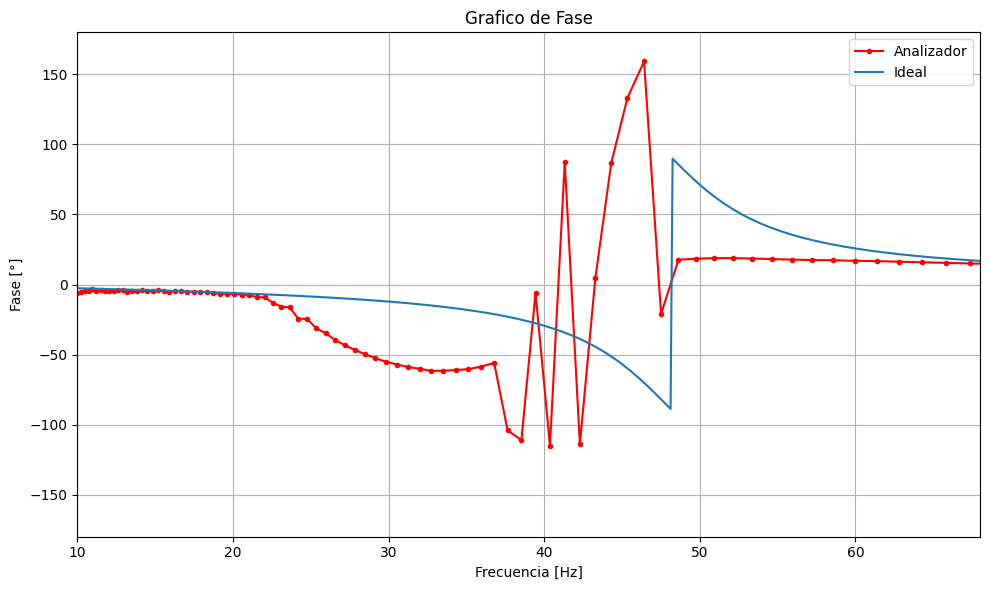

In [25]:
# ----------------------------
# -----  Gráfico 1: ----------
#-----------------------------
    # Gráfico hecho con el archivo fase.csv medido en el laboratorio con el Analizador de Audio:
datos = pd.read_csv('fase.csv', skiprows=2)

frecuencia = datos['X (Hz)']
Psi = datos['Ch-1 ']

plt.figure(figsize=(10, 6))
plt.plot(frecuencia, Psi, color='red', marker='.', linestyle='-', label='Analizador')

# ----------------------------
# -----  Gráfico 2: ----------
#-----------------------------
    # Gráfico de comportamiendo ideal con nuestros componentes de la fase:
# Datos:
num = [ 1 , 0 , 9.183e4 ]
den = [ 1 , 64.28 , 9.183e4 ]

# Transferencia
H = TransferFunction(num, den)
frecuencia = np.linspace(4, 68, 500)

# Respuesta en frecuencia de la fase en grados
_, H = H.freqresp(2 * np.pi * frecuencia)
fase = np.angle(H, deg=True)

plt.plot(frecuencia, fase, label='Ideal')

# ----------------------------
plt.title('Grafico de Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [°]')
plt.xlim(10, 68)
plt.ylim(-180, 180)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

#### **Conclusiones**

Como se pueden observar en los gráficos superiores, estos no satisfacen lo esperado en la simulación. Esto puede deberse a la dispersión en los valores de los componentes (en gran medida, de la tolerancia de los capacitores) ya que pequeñas variaciones en estos pueden ocasionar que el filtro no funcione correctamente, especialmente, en un Filtro Notch. Otra de las posibles causas es el hecho de que se utilizaron solo dos operacionales a diferencia de otras topologías mas robustas (como puede ser la Ackerber-Mossberg). Concretamente, en el gráfico de módulo hay una discrepancia entre lo que se midió con el osciloscopio y lo que se midió con el analizador de audio, creemos que esto se debe a un error de lectura del osciloscopio que se arrastre hasta generar esa diferencia o, por otro lado, las condiciones en las que se midió con el analizador de audio no eran las mismas que las que se usaron para medir con el osciloscopio, es curioso ver cómo el gráfico de los puntos del osciloscopio se acerca más al gráfico verdadero e ideal que el gráfico del analizador de audio. Por el lado del gráfico de la fase, se puede detectar que la misma sufre un glitch en la zona crítica, esto creemos que puede deberse a la cantidad de puntos que decidimos gráficar en el analizador de audio.

Para mejorar, se pudieron haber usado componentes con menor incertidumbre, mejores conectores y estrategias para reducir el ruido, como resistencias o capacitores variables de compensación.